# Water Potability

In this analysis, I explored the dataset Water Potability,  which contains 3276 entries and 9 features. 

**Objective**

Predict the potability of the water based on the values of its features: pH, hardness, solids, chloramines, sulfate, conductivity, organic carbon, trihalomethanes, and turbidity.


An extensive explanation of the features and the link to download the dataset  is provided on the Kaggle page [Water_Potability](https://www.kaggle.com/datasets/adityakadiwal/water-potability).

The analysis begins with exploratory data analysis (EDA) to understand the data distribution, statistical measures, and quality. I found that approximately 11% of data entries are outliers, and around 44% of the data contain missing values. To prepare the data for modeling, I followed the multi-step preprocessing approach:

* Outlier treatment using IQR capping to reduce the impact of extreme values.

* Missing value imputation using the k-Nearest Neighbors (kNN) algorithm.

For modeling, I implemented two machine learning classifiers:

* Support Vector Machine (SVM): Before imputation, I applied a RobustScaler to mitigate the effect of outliers during scaling.

* Random Forest: Since tree-based models are less sensitive to feature scaling, I skipped scaling for this model.



In [1]:
# Basic modules
import numpy as np
import pandas as pd
import os
import math

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistic
import scipy.stats as stats
from scipy.stats import skew

# library from the preprocessing Module.
from sklearn.preprocessing import  RobustScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

# SVM
from sklearn import svm
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score,  recall_score
from sklearn.model_selection import validation_curve


# RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree

import warnings
warnings.filterwarnings('ignore')

## 1) Download data

In [2]:
# Install new Kaggels version
#!pip install --upgrade kagglehub

In [3]:
# Download the dataset from the Kaggle page
import kagglehub

path = kagglehub.dataset_download("adityakadiwal/water-potability")
# List the files in the path to find the exact filename
print("Files in directory:", os.listdir(path))


Files in directory: ['water_potability.csv']


In [4]:
# Load the CSV data
file_path = os.path.join(path, 'water_potability.csv')
df = pd.read_csv(file_path)

### a) General and statistical information

In [5]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [6]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


🔍 This shows that: 
* The dataset contains 3,276 rows and 10 columns.
* There are missing values in columns *ph, Sulfate* and *Trihalomethanes*.

### b) Distribution of Potability classes

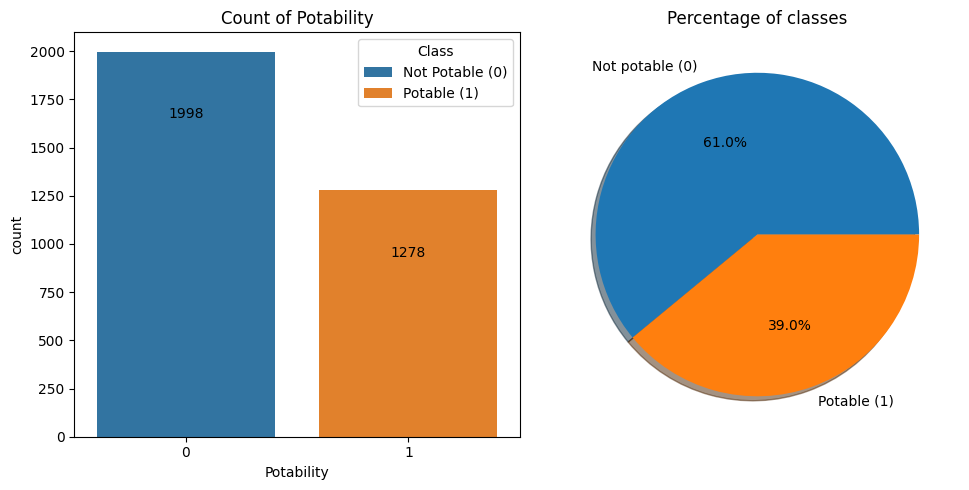

In [7]:
#========================================
# Counting the number of classes in Rain
#========================================

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# bar plot
sns.countplot(data=df, x="Potability", hue="Potability",  ax=ax[0])
# count labels above bars
for c in ax[0].containers:
    ax[0].bar_label(c, padding=-50)
ax[0].set_title('Count of Potability')
ax[0].legend(title="Class", labels=['Not Potable (0)', 'Potable (1)'])

#pie plot
potability_counts = df['Potability'].value_counts()
potability_labels = {0: 'Not potable (0)', 1: 'Potable (1)'}  # Potable -> 1 and Not potable -> 0
# Apply the mapping to the index of the value counts Series
potability_counts.index = potability_counts.index.map(potability_labels)

# Plot the pie chart using the re-indexed value counts
potability_counts.plot.pie(
    autopct='%1.1f%%', 
    shadow=True, 
    textprops={'fontsize': 10}, 
    ylabel='',
    ax=ax[1]
)
ax[1].set_title('Percentage of classes')
plt.tight_layout()
plt.show()

🔍 The dataset is moderately imbalanced; over half of the samples represent non-potable water. 

### c) Distribution information

In [8]:
# Statistical information
# Pandas ignores NaN values by default when calculating descriptive statistics.
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


🔍
 
* For *Solids*, the difference between the minimum and maximum values spans up to three orders of magnitude compared to the other columns.
  
* The variables have different ranges; in particular, the *Solids* feature has a significantly larger range of values than the rest.

* By comparing the mean and median (50th percentile), we observe a small gap between them in the *Solids* column, indicating a positively skewed distribution.
In contrast, the remaining columns exhibit Gaussian-like distributions, as the differences between their means and medians are minimal.


The following distribution plots support the last three observations.

### d) Visualization with Descriptive Statistic 

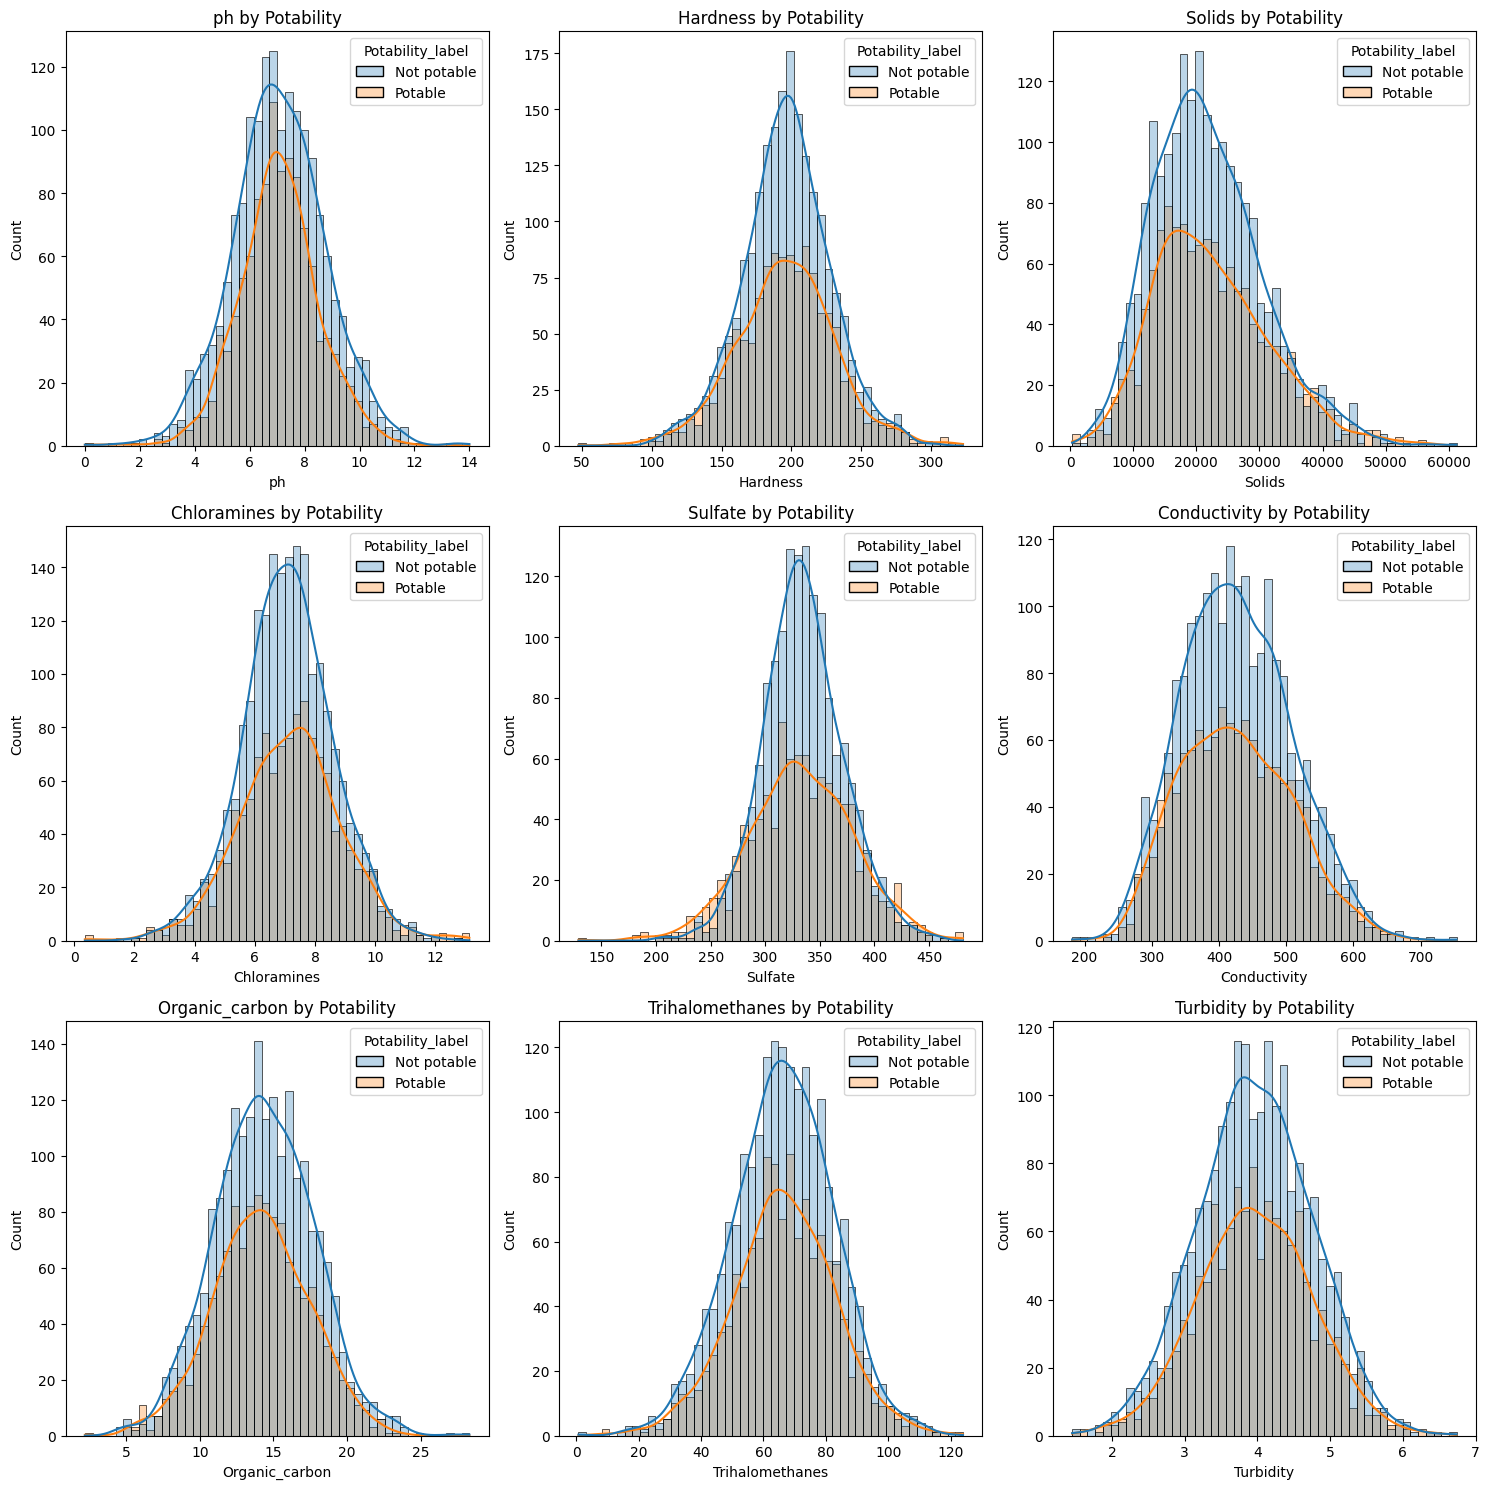

In [9]:
# Histograms with hue for Potability

# Create  a data frame for the plot
df_plot = df.copy()
# Create label column
df_plot['Potability_label'] = df_plot['Potability'].map({0: 'Not potable', 1: 'Potable'})


# Select  features
features = [col for col in df_plot.columns if col not in ['Potability', 'Potability_label']]

n_cols = len(features)
n_rows = math.ceil(n_cols / 3)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(features):
    plt.subplot(n_rows, 3, i + 1)

    sns.histplot(
        data=df_plot,
        x=col,
        hue='Potability_label',
        kde=True,
        bins=50,
        alpha=0.3
    )

    plt.title(f'{col} by Potability')

plt.tight_layout()
plt.show()

🔍 
* The distribution for *Solids* shows a moderate positive skew, as the tail on the right side is longer than the tail on the left. *Conductivity* also exhibits a slight positive skew. The remaining columns display only minimal skewness, which is small enough that their distributions can be considered approximately Gaussian.

* Another interesting observation is that this dataset has class overlapping. It means that features in both classes share a similar range, and their density plots are very similar.

In [10]:
# compute the skewness
df.groupby(['Potability']).skew(skipna = True).round(2)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
Potability,,,,,,,,,
0,0.04,-0.02,0.61,-0.02,0.12,0.26,0.07,-0.10,-0.01
1,-0.02,-0.05,0.63,-0.02,-0.11,0.27,-0.05,-0.06,-0.01


🔍 In effect, we observe that *Solids* has a moderate skewness of 0.6, *Sulfate* has a light skewness of 0.1, and the rest of the variables can be considered perfectly symmetric with a skewness near 0. 

👉 In this analysis, I decided not to apply a log transformation to the Solids variable, as its skewness (0.6) is not high enough to  bias the model significantly.

## Bivariate Analysis
###  e) Scatter Plots 

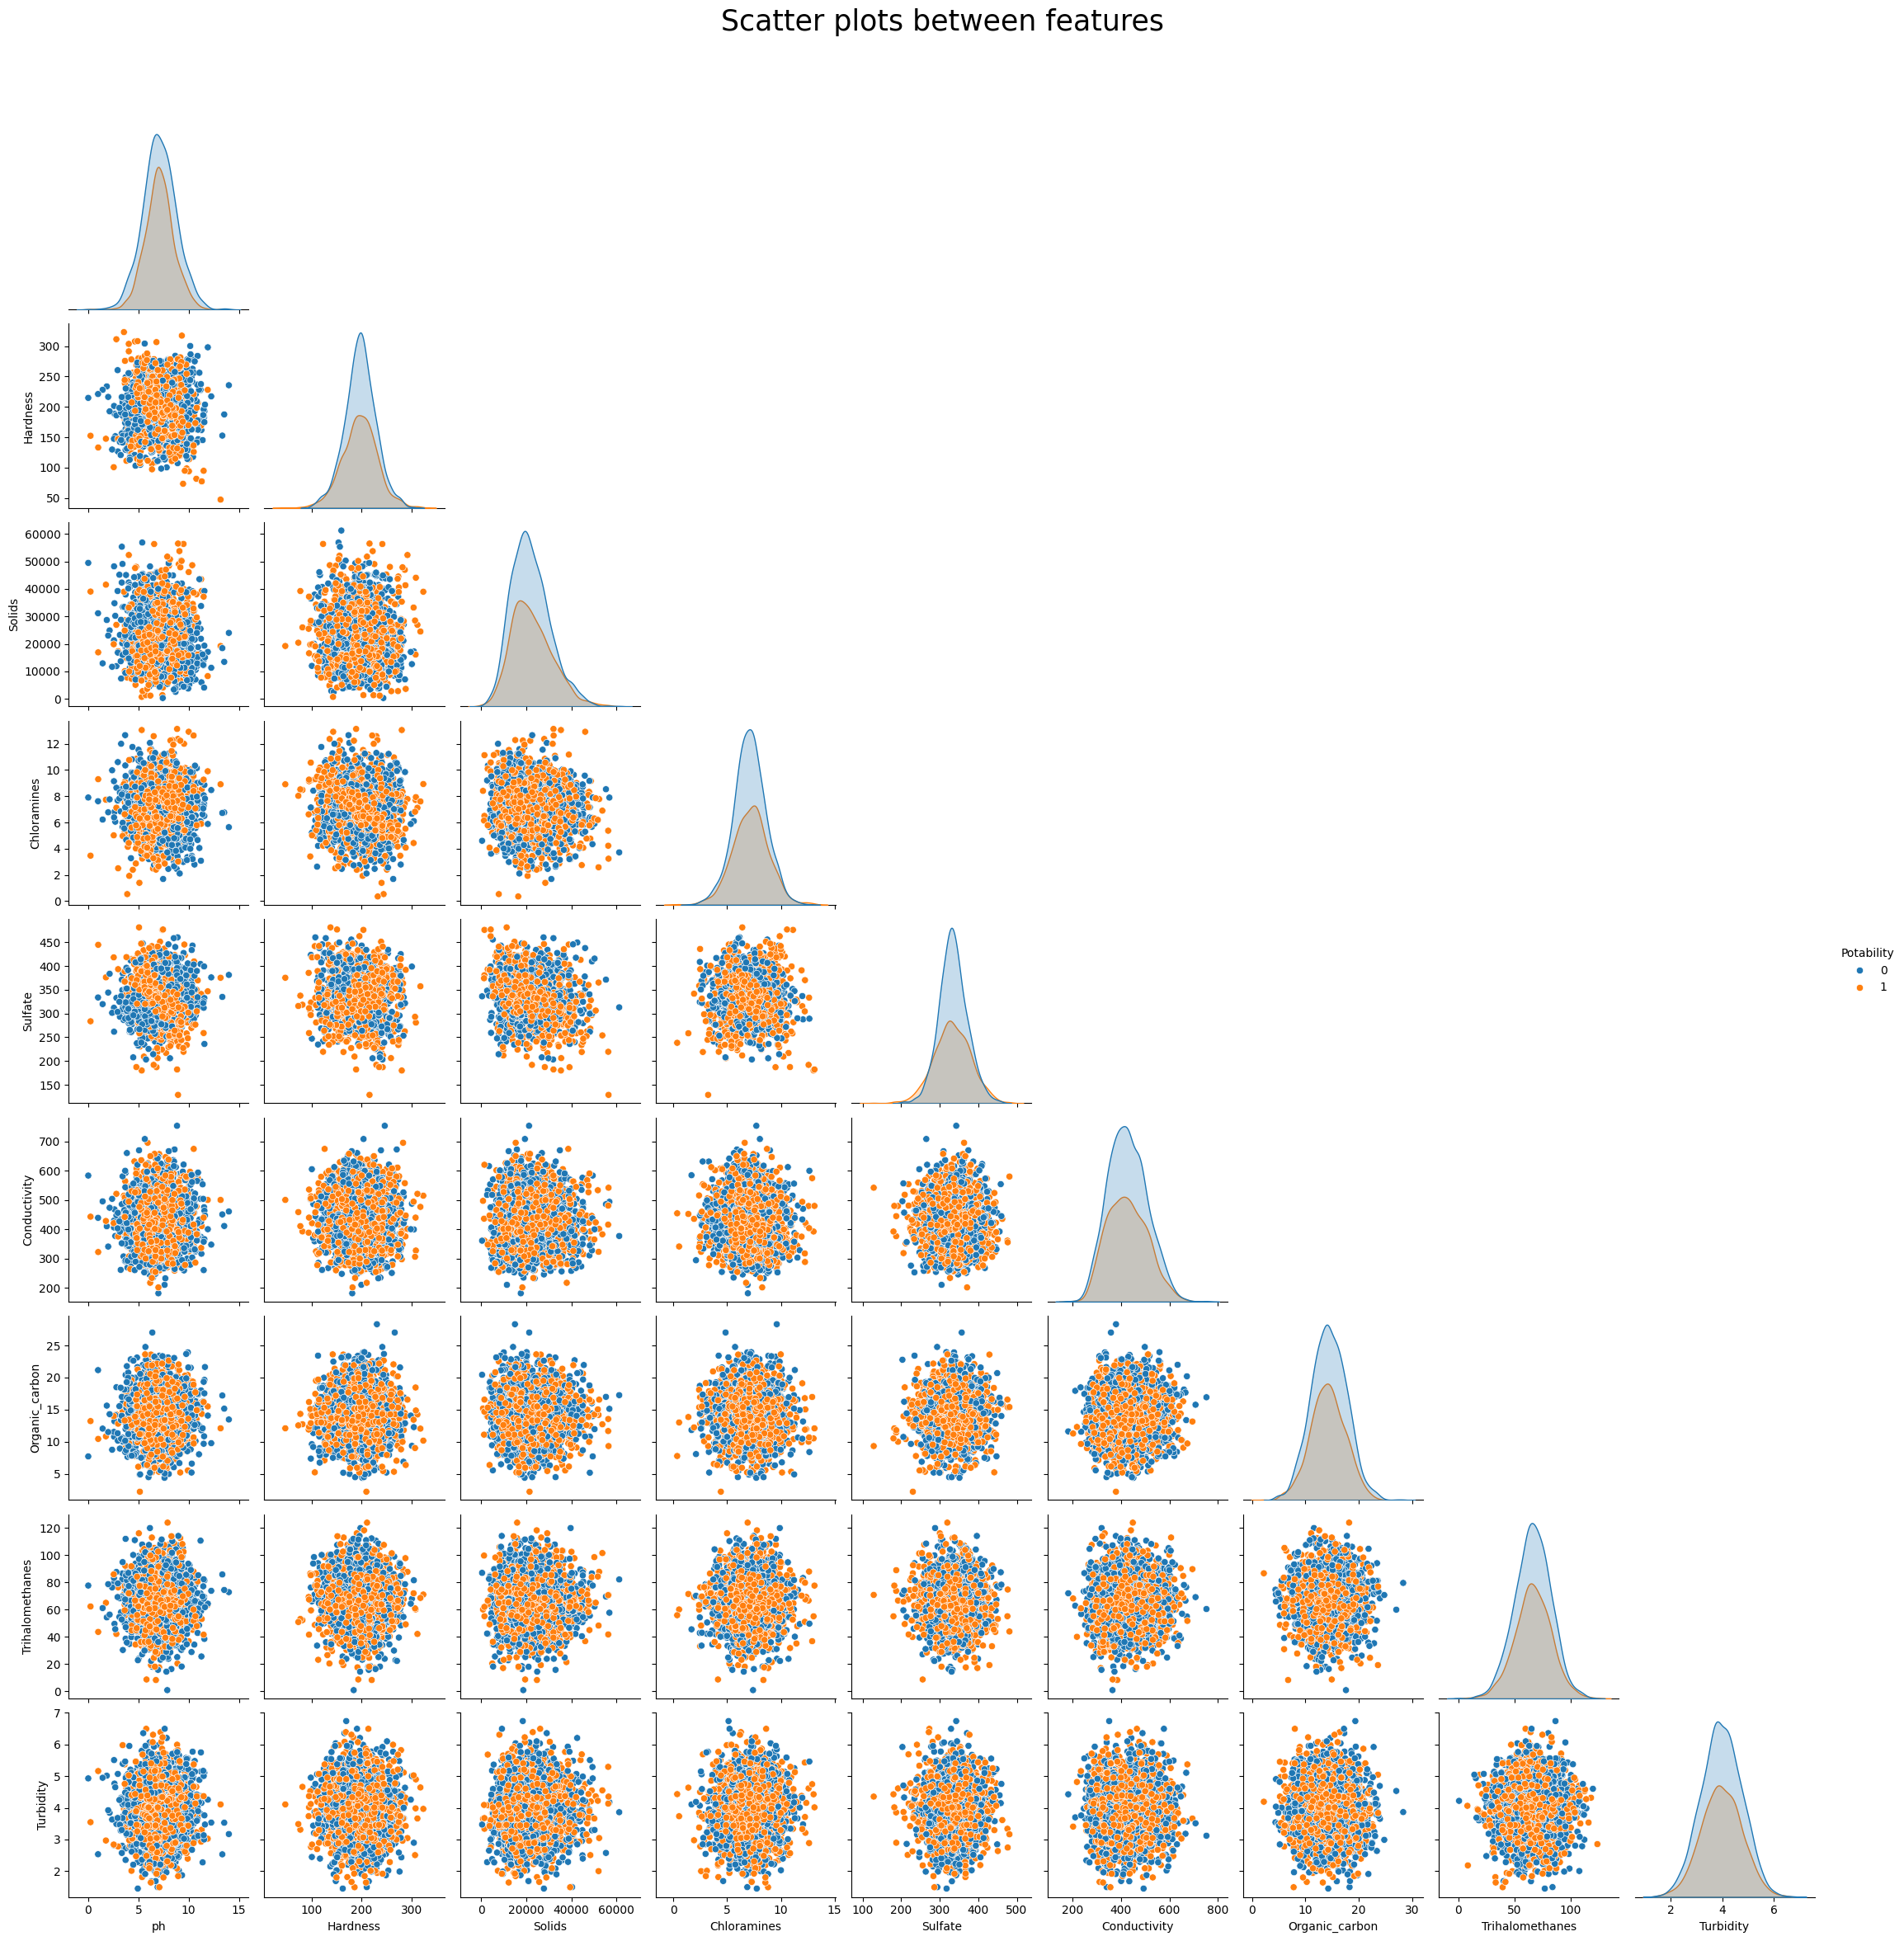

In [11]:
scatter = sns.pairplot(df, hue='Potability', corner = True, diag_kind="kde")
# Add the title
scatter.fig.suptitle(
    "Scatter plots between features",
    y=1.05,
    fontsize=25   
)
plt.show()

### f) Correlation between features


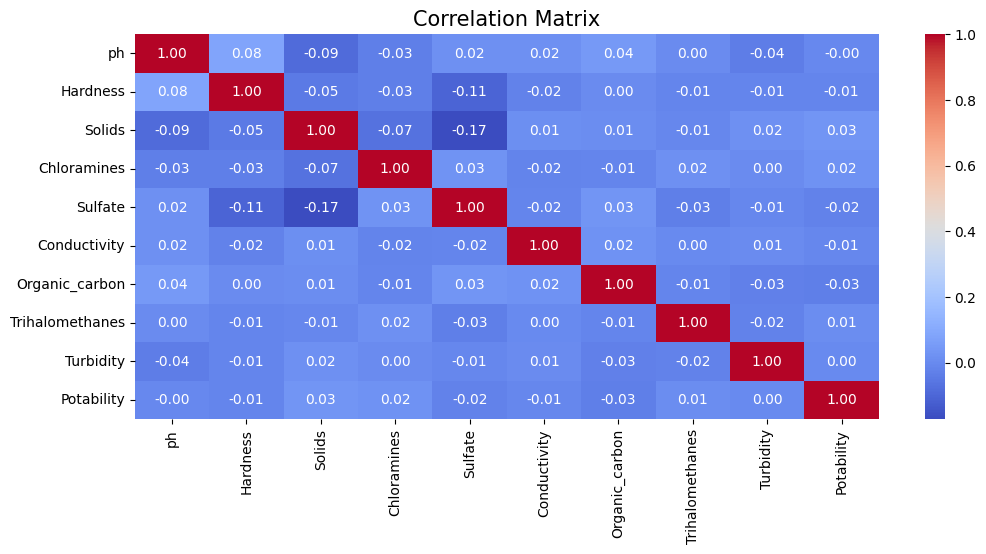

In [12]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix", fontsize=15) # 
plt.show()

🔍 The scatter plots and the correlation matrix show that there is not a clear  linear relationship between the variables. 

### g) Missing Values

In [13]:
# The number of missing values
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [14]:
# Percentage of missing values
missing_percentage_ph = (df['ph'].isnull().sum() / len(df)) * 100
missing_percentage_sf = (df['Sulfate'].isnull().sum() / len(df)) * 100
missing_percentage_tr = (df['Trihalomethanes'].isnull().sum() / len(df)) * 100
missing_percentage_total = (df.isnull().sum().sum() / len(df)) * 100

print(f"Porcentage of missing values in  'ph':  {missing_percentage_ph:.2f}%")
print(f"Porcentage of missing values in  'Sulfate':  {missing_percentage_sf:.2f}%")
print(f"Porcentaje  of missing values in 'Trihalomethanes':  {missing_percentage_tr:.2f}%")
print(f"Total Porcentaje  of missing values:  {missing_percentage_total:.2f}%")

Porcentage of missing values in  'ph':  14.99%
Porcentage of missing values in  'Sulfate':  23.84%
Porcentaje  of missing values in 'Trihalomethanes':  4.95%
Total Porcentaje  of missing values:  43.77%


Before handling missing values, we need to understand their pattern of occurrence.

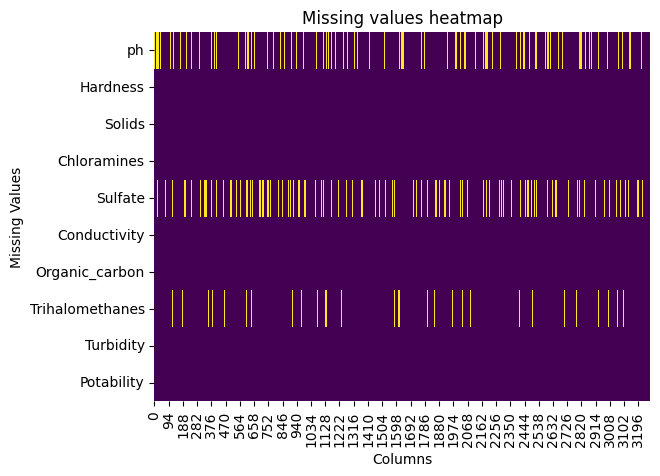

In [15]:
# Missing values heatmap
ax = plt.axes()
sns.heatmap(df.isna().transpose(),cbar=False, cmap = "viridis",ax = ax)
#labels and titles
plt.xlabel("Columns", fontsize = 10)
plt.ylabel("Missing Values", fontsize = 10)
plt.title("Missing values heatmap")
plt.show()

🔍 The missing values in *pH* appear in chunks, while in *Sulfate* they are more evenly distributed across the rows. In *Trihalomethanes*, the missing values are sparsely scattered. Overall, no clear pattern is evident in the missing data.

Are the missing values distributed along the two classes? Yes, they are.

In [16]:
df.isnull().groupby(df['Potability']).sum()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
Potability,,,,,,,,,,
0,314,0,0,0,488,0,0,107,0,0
1,177,0,0,0,293,0,0,55,0,0


### h) Outliers

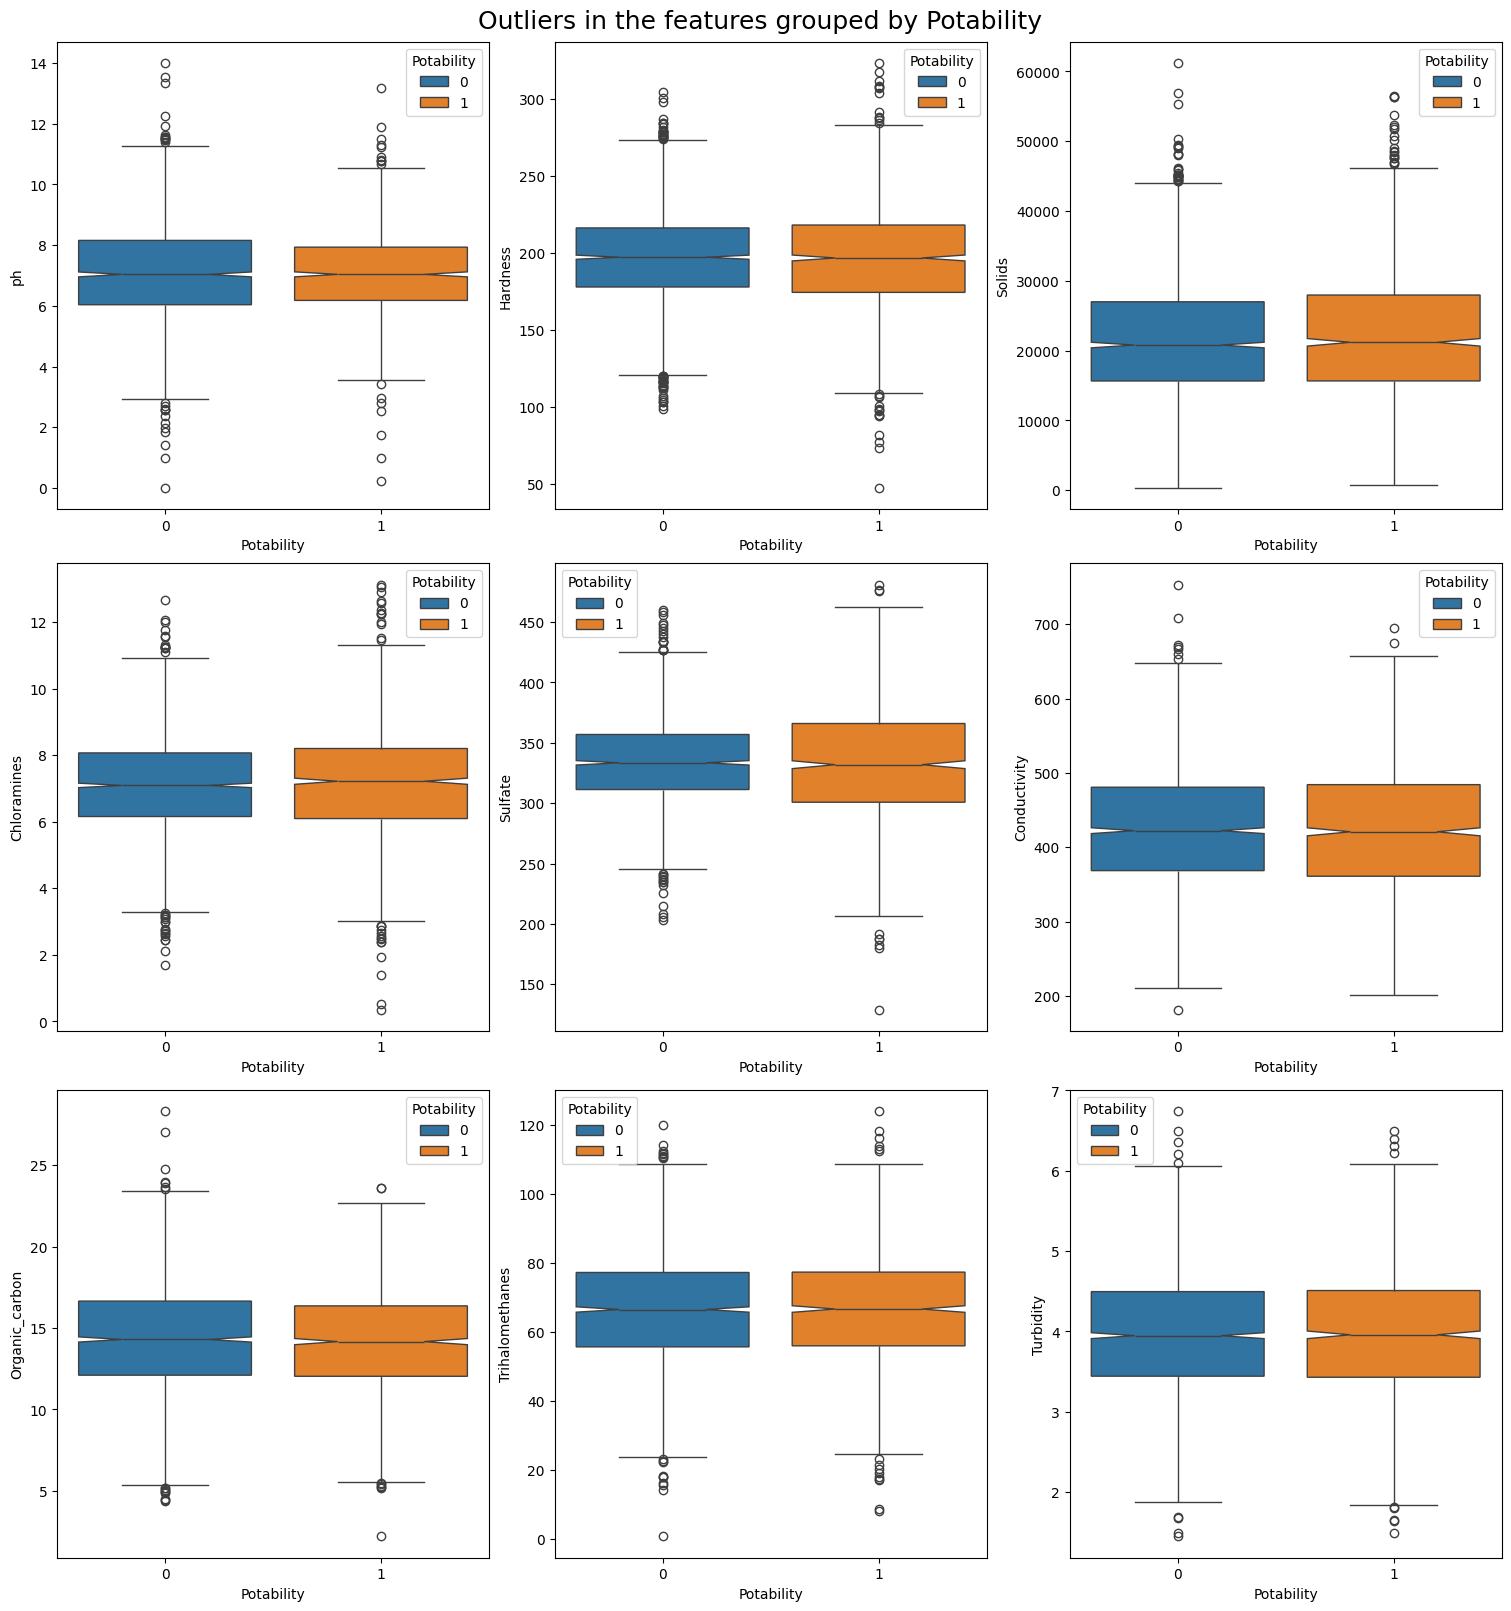

In [17]:
# Plot Outliers
fig, axes = plt.subplots(3, 3, constrained_layout=True, figsize=(15, 16)) 
axes = axes.flatten()

# List of columns to plot 
columns_to_plot = ["ph", "Hardness", "Solids", "Chloramines", "Sulfate", "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]

# Loop through the columns and plot
for i, col in enumerate(columns_to_plot):
    sns.boxplot(x="Potability", y=col, data=df, orient='v',  ax=axes[i], hue = "Potability" ,notch=True,)

fig.suptitle(" Outliers in the features grouped by Potability", fontsize = 18)
plt.show()

 🔍 All variables have outliers, but *Hardness* is the column with the most number of outliers as can be seen in the following table. 

In [18]:
# Count outliers
def outliers(df):
  Q1 = df.quantile(0.25)
  Q3 = df.quantile(0.75)
  IQR = Q3 - Q1
  outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))
  return outliers


outliers_df = outliers(df)
pd.DataFrame({"Count.Outliers": outliers_df.sum(),
            "Pct.Outliers %": (outliers_df.sum() * 100/ len(df)).round(2)})

,Count.Outliers,Pct.Outliers %
ph,46,1.40
Hardness,83,2.53
Solids,47,1.43
Chloramines,61,1.86
Sulfate,41,1.25
Conductivity,11,0.34
Organic_carbon,25,0.76
Trihalomethanes,33,1.01
Turbidity,19,0.58
Potability,0,0.00


In [19]:
print(f" Total percentage of outliers: {((outliers_df.sum().sum()/ len(df)) * 100):.2f} %")

 Total percentage of outliers: 11.17 %


🔍
This dataset has 43.8% missing values and 11.17% outliers.

👉 Since there are fewer outliers than missing values, I handled the outliers first. This prevents extreme values from affecting the calculation of the mean or median used for imputation

## 3) Preprocessing

### a) Capping Outliers with Inter Quantile Range (IQR)

In [20]:
# apply cap with IQR
def cap_outliers_iqr(df):
  Q1 = df.quantile(0.25)
  Q3 = df.quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = ((df < lower_bound) | (df > upper_bound))
  return np.clip(df, lower_bound, upper_bound)

df_cap_iqr = df.groupby('Potability').transform(cap_outliers_iqr)


outliers_df_cap_iqr = outliers(df_cap_iqr)
pd.DataFrame({"Count.Outliers": outliers_df_cap_iqr.sum(),
            "Pct.Outliers %": (outliers_df_cap_iqr.sum() * 100/ len(df_cap_iqr)).round(2)})

print(f" Total percentage of outliers after capping: {((outliers_df_cap_iqr.sum().sum()/ len(df)) * 100):.2f} %")

 Total percentage of outliers after capping: 6.65 %


🔍 By applying capping, I successfully reduced the presence of outliers from 11.17% to 6.65%. This reduction strikes a balance between cleaning the data and preserving the natural variance of the water quality metrics, ensuring a more robust dataset for model training

### b) Separate data into features and target

In [21]:
# separate data
X= df_cap_iqr
y=df["Potability"]

### c) Splitting data and applying a robust scaler


👉 I selected K-Nearest Neighbors (KNN) for imputing the missing values. To do this, I first scaled the data, as KNN is sensitive to feature scaling. The target variable in this analysis is Potability.

👉 I used Robust Scaler since it scales features using statistics that are robust to outliers. I selected the parameters in the Robust scaler such that the data are translated to have a median of 0 and scaled according to the IQR range. 

In [22]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale with Robust Scaler
scaler = RobustScaler(with_scaling=True, with_centering = True, quantile_range=(25.0, 75.0))

# scaler fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)
# transform test with the training information
X_test_scaled = scaler.transform(X_test)

### d) K-Nearest Neighbors (KNN) imputation of missing values

In [23]:
# Create an instance of KNNImputer
imputer = KNNImputer(n_neighbors=10, weights="uniform") 

# Apply KNN imputation, fit, and transform
X_train_knn = imputer.fit_transform(X_train_scaled)
X_test_knn = imputer.transform(X_test_scaled)

# Verify that missing values are gone
print("\nMissing values after KNN imputation:")
print(f"Total missing values in X_train_knn: {np.isnan(X_train_knn).sum()}")
print(f"Total missing values in X_test_knn: {np.isnan(X_test_knn).sum()}")



Missing values after KNN imputation:
Total missing values in X_train_knn: 0
Total missing values in X_test_knn: 0


In [24]:
# Checking the statistical information 
X_train_knn_df = pd.DataFrame(X_train_knn, columns=X.columns)

X_train_knn_df.describe().apply(lambda x: x.apply('{:.4f}'.format))

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2620.0000,2620.0000,2620.0000,2620.0000,2620.0000,2620.0000,2620.0000,2620.0000,2620.0000
mean,0.0356,-0.0113,0.0947,0.0006,0.0225,0.0372,0.0212,-0.0112,0.0180
std,0.7394,0.8039,0.7545,0.7804,0.6930,0.7002,0.7322,0.7243,0.7264
min,-2.1321,-2.2099,-1.7609,-2.0966,-2.4907,-1.9209,-1.9879,-1.9962,-1.9919
25%,-0.3918,-0.5035,-0.4521,-0.5020,-0.3480,-0.4878,-0.4706,-0.4742,-0.4786
50%,0.0118,-0.0000,-0.0000,0.0000,0.0170,-0.0000,0.0000,0.0008,-0.0000
75%,0.4603,0.4965,0.5479,0.4980,0.3883,0.5122,0.5294,0.4708,0.5214
max,2.2090,2.1730,2.2245,2.1364,2.5134,2.1387,2.0863,1.9843,2.0472


In [25]:
X_train.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2225.000000,2620.000000,2620.000000,2620.000000,1989.000000,2620.000000,2620.000000,2493.000000,2620.000000
mean,7.091406,196.451425,22006.858392,7.108327,333.710687,426.325442,14.250399,66.368362,3.959876
std,1.547887,32.040596,8652.176500,1.552505,40.732968,80.844532,3.269909,16.058072,0.775955
min,2.861042,108.821198,728.750830,2.936442,202.997411,200.230529,5.278416,23.349768,1.812920
25%,6.106760,176.832962,15736.815715,6.108402,307.987458,365.712099,12.054236,55.697400,3.429438
50%,7.021617,196.901673,20921.203012,7.107117,332.759029,422.033283,14.155598,66.621027,3.940678
75%,8.058136,216.690772,27203.707180,8.097686,360.086901,481.179357,16.519916,77.373813,4.497655
max,11.332191,283.512754,46429.613564,11.356953,463.707707,668.981244,23.472127,109.634466,6.127557


Comparing these tables, we observe: 
* For example, the ph variable in X_train increased from 2,225 to 2,620 values after missing data was imputed using a 10-neighbor KNN approach.
* The median in X_train after knn imputation is 0 for all variables; we fixed this with the Robust Scaler transformation.
  

## 4) Support Vector Machine (SVM)

Because there are still outliers, I have applied SVM for the analysis to ensure the model remains robust despite the presence of outliers in the dataset.
Since we have seen from the scatter plots that there is no linear relation between features, then the best kernel to be used in this case is RBF. in any case, I have applied a linear kernel just for exploration. 

### a) Linear kernel

In [26]:
# Create the model: linear model
linear_model = SVC(kernel='linear',C=0.5)

# Train the model with the training data
linear_model_train = linear_model.fit(X_train_knn, y_train)

# Predict with the test data
y_pred_linear = linear_model_train.predict(X_test_knn)

In [27]:
# Calculating the accuracy of the linear model
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear SVM Accuracy: {accuracy_linear:.2f}")

# Displaying confusion matrix and classification report for the linear model
conf_matrix_linear = confusion_matrix(y_test, y_pred_linear)
linear_svm_report = classification_report(y_test, y_pred_linear)

print("\nConfusion Matrix (Linear SVM):")
print(conf_matrix_linear)


tnl, fpl, fnl, tpl = conf_matrix_linear.ravel()
print(f"True Negatives: {tnl}, False Positives: {fpl}, False Negatives: {fnl}, True Positives: {tpl}")



print("\nClassification Report (Linear SVM):")
print(linear_svm_report)


Linear SVM Accuracy: 0.63

Confusion Matrix (Linear SVM):
[[412   0]
 [244   0]]
True Negatives: 412, False Positives: 0, False Negatives: 244, True Positives: 0

Classification Report (Linear SVM):
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656



The linear SVM is evidently ineffective, as it fails to identify any true positives.

## b) Radial Basic Function (RBF) kernel

#### Tuning the hyperparameters for the Radial Basic Function (RBF) kernel

In [28]:
# list to record the accuracy
training_accuracy = []
testing_accuracy = []

# list to record the error
training_error = []
testing_error = []

# C Hyperparameter - Define a list of specific C values
C_param = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]


for C_value in C_param:
    # Create the SVC model with a C_value
    rbf_model = SVC(kernel='rbf', C=C_value,class_weight='balanced')
    rbf_model.fit(X_train_knn, y_train) # train the model

    # Appending the Accuracy Score
    training_accuracy.append(rbf_model.score(X_train_knn, y_train))
    testing_accuracy.append(rbf_model.score(X_test_knn, y_test))

    # Appending the Error Score
    training_error.append(1 - rbf_model.score(X_train_knn, y_train))
    testing_error.append(1 - rbf_model.score(X_test_knn, y_test))

# Find the best C based on testing accuracy
best_C_index = np.argmax(testing_accuracy)
best_C = C_param[best_C_index]

print(f"Best C value based on testing accuracy: {best_C}")
print(f"Corresponding training accuracy: {training_accuracy[best_C_index]:.2f}")
print(f"Corresponding testing accuracy: {testing_accuracy[best_C_index]:.2f}")





Best C value based on testing accuracy: 0.1
Corresponding training accuracy: 0.69
Corresponding testing accuracy: 0.65


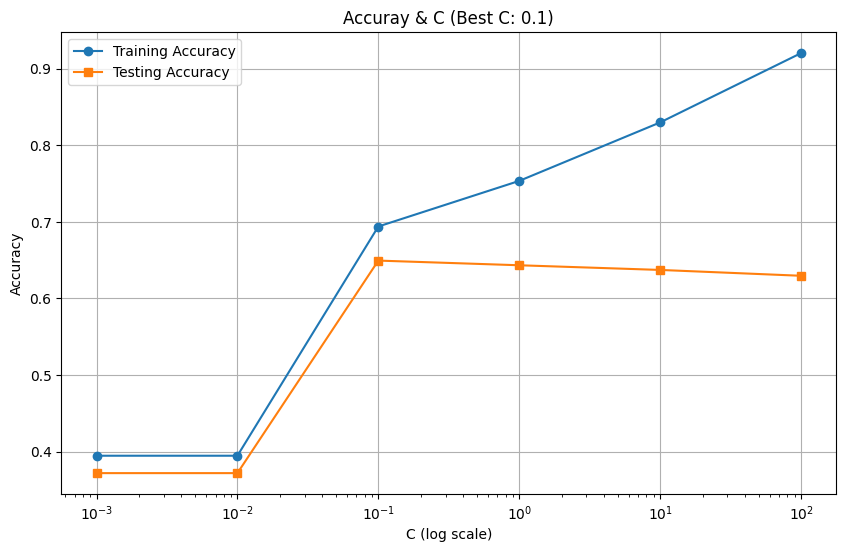

In [29]:
plt.figure(figsize=(10, 6))
plt.semilogx(C_param, training_accuracy, label="Training Accuracy", marker='o')
plt.semilogx(C_param, testing_accuracy, label="Testing Accuracy", marker='s')

plt.title(f"Accuray & C (Best C: {best_C})")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

🔍 Between $10^{-3}$ and $10^{-2}$, there is underfitting, as both curves show similarly low values. Above $10^{-1}$, the model starts to overfit; the training curve rises and diverges from the testing curve

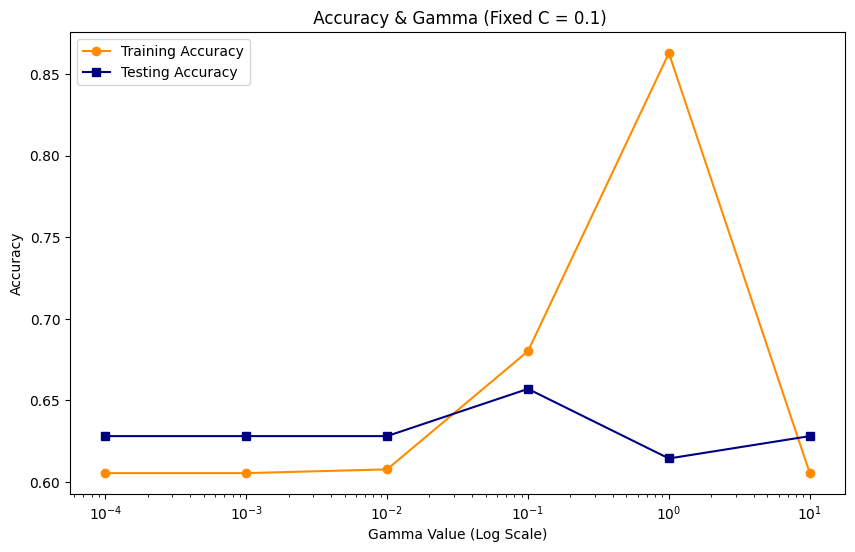

Best Gamma value: 0.1
Max Testing Accuracy: 0.6570


In [30]:
# 1. Prepare lists to record the results
gamma_training_accuracy = []
gamma_testing_accuracy = []
gamma_training_error = []
gamma_testing_error = []

# Define specific Gamma values (using powers of 10)
# We use the Best C found in the previous step (0.1)
gamma_param = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
best_c_value = 0.1 

for g_value in gamma_param:
    # Create the model with fixed C and varying Gamma
    rbf_model = SVC(kernel='rbf', C=best_c_value, gamma=g_value, class_weight='balanced')
    
    # Fit the model
    rbf_model.fit(X_train_knn, y_train)
    
    # Calculate scores
    train_acc = rbf_model.score(X_train_knn, y_train)
    test_acc = rbf_model.score(X_test_knn, y_test)
    
    # Append to Accuracy lists
    gamma_training_accuracy.append(train_acc)
    gamma_testing_accuracy.append(test_acc)
    
    # Append to Error lists
    gamma_training_error.append(1 - train_acc)
    gamma_testing_error.append(1 - test_acc)

# 2. Find the best Gamma based on testing accuracy
best_gamma_idx = np.argmax(gamma_testing_accuracy)
best_gamma = gamma_param[best_gamma_idx]

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.semilogx(gamma_param, gamma_training_accuracy, label="Training Accuracy", marker='o', color='darkorange')
plt.semilogx(gamma_param, gamma_testing_accuracy, label="Testing Accuracy", marker='s', color='navy')

plt.title(f" Accuracy & Gamma (Fixed C = {best_c_value})")
plt.xlabel("Gamma Value (Log Scale)")
plt.ylabel("Accuracy")
plt.legend()
#plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

print(f"Best Gamma value: {best_gamma}")
print(f"Max Testing Accuracy: {gamma_testing_accuracy[best_gamma_idx]:.4f}")

🔍 
* The testing accuracy curve reaches its highest point at $\gamma = 10^{-1}$.  Below this value, the model suffers from underfitting. On the other hand, for $\gamma$ values above $10^{-1}$, we observe severe overfitting: while training accuracy significantly increases, testing accuracy drops back to baseline levels, indicating that the model is failing to generalize and is instead memorizing noise in the training set.

* The best values  for the hyperparameters are  $C = 0.1$ and $\gamma = 0.1$

In [31]:
# Create an RBF model classifier
rbf_model = SVC(kernel='rbf', C=0.1, class_weight='balanced', gamma = 0.1)

# Train the model with the training data
rbf_model_train = rbf_model.fit(X_train_knn, y_train)

# Predict with the test  and train
y_test_pred_rbf = rbf_model_train.predict(X_test_knn)  # predict with unseen data
y_train_pred_rbf = rbf_model_train.predict(X_train_knn) # predict with training data

In [32]:
# Classification evaluation

rbf_svm_report = classification_report(y_test, y_test_pred_rbf)
print(rbf_svm_report)

              precision    recall  f1-score   support

           0       0.68      0.85      0.76       412
           1       0.57      0.33      0.42       244

    accuracy                           0.66       656
   macro avg       0.62      0.59      0.59       656
weighted avg       0.64      0.66      0.63       656



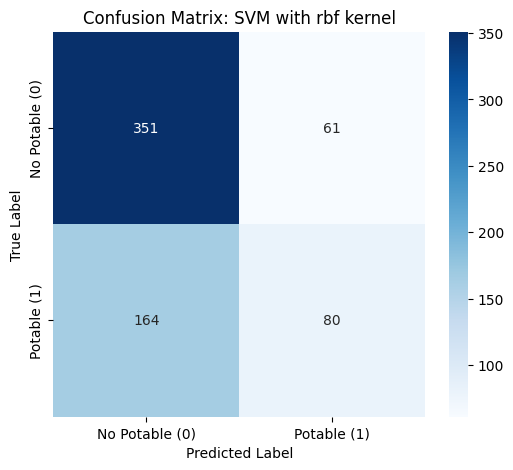

In [45]:
# Calculate the confusion matrix
cm_svm = confusion_matrix(y_test, y_test_pred_rbf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Potable (0)', 'Potable (1)'],
            yticklabels=['No Potable (0)', 'Potable (1)'])
plt.title(f"Confusion Matrix: SVM with rbf kernel")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()





🔍 

* The overall accuracy is moderate (66%), but this metric alone is insufficient due to the imbalance between classes. For  an imbalanced dataset, **recall and F1-score** are more appropriate evaluation metrics than accuracy.
* For the positive class (potable water), the model correctly identifies 80 samples (True Positives) but still misses 61 cases (False Negatives), resulting in a recall of 0.33.
* The model performs well on the negative class (non-potable water), achieving a recall of 0.85, indicating strong detection of unsafe water.
* However, performance on the positive class remains limited, as reflected by both low recall and F1-score.



To further improve these results, I implemented a Random Forest classifier below to compare its performance against the SVM results.


Next, the KDE plot illustrates the probability distributions of the actual and predicted values. There is a visible gap between the curves  where potability equals 1. This gap indicate that the model’s predicted values differ noticeably from the true values for the potable class  and that the model isn't capturing the underlying distribution well for that class, signaling room for improvement.

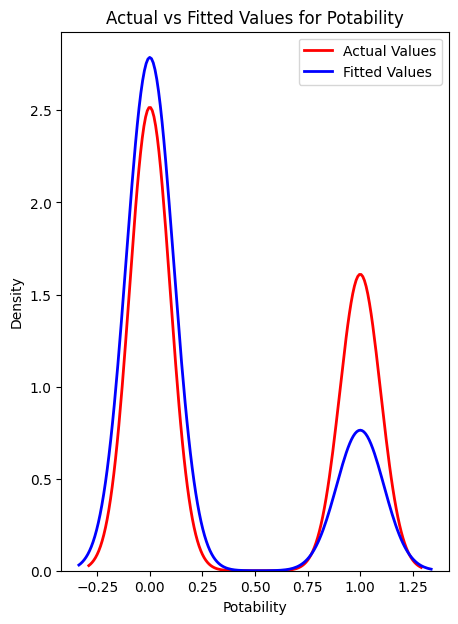

In [34]:
plt.figure(figsize=(5, 7))

# Plot actual values
ax = sns.kdeplot(y, color="r", label="Actual Values", linewidth=2)

# Plot predicted values
sns.kdeplot(y_test_pred_rbf, color="b", label="Fitted Values", ax=ax, linewidth=2)

# Add labels and title
plt.title('Actual vs Fitted Values for Potability')
plt.xlabel('Potability')
plt.ylabel('Density')

# Add legend with location specified
plt.legend(loc='upper right')

# Show and close plot
plt.show()
plt.close()

In [46]:
model = SVC(kernel='rbf', C=0.1,class_weight='balanced', gamma = 0.1, probability=True)
# Train the model with the training data
model.fit(X_train_knn, y_train)
proba_pred = model.predict_proba(X_test_knn)

# Probability
prob_pot_svm = pd.DataFrame(proba_pred, columns=['P(y=0|X)', 'P(y=1|X)'])
prob_pot_svm.head(15)

,P(y=0|X),P(y=1|X)
0,0.725763,0.274237
1,0.690913,0.309087
2,0.696113,0.303887
3,0.572454,0.427546
4,0.655022,0.344978
5,0.428648,0.571352
6,0.569448,0.430552
7,0.457200,0.542800
8,0.471261,0.528739
9,0.682061,0.317939


## 5) Random Forest

With the aim of improving model performance, I have implemented a Random Forest classifier as an alternative to the SVM

Standarization or normalization is not needed for tree bases models. Therefore, I just consider the missing values imputation.

In [36]:
# Create an instance of KNNImputer without scale
imputer_knn = KNNImputer(n_neighbors=15, weights="uniform") # default values for weights = uniform and metric = nan_euclidean

# Apply KNN imputation, fit and transform
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Verify that missing values are gone
print("\nMissing values after KNN imputation:")
print(sum(np.isnan(X_train_imp)))


Missing values after KNN imputation:
[0 0 0 0 0 0 0 0 0]


#### Tuning the hyperparameters
Looking for the best model for different values of the hyperparameters.

In [37]:
# define interval of parameters 
param_dist = {'n_estimators': randint(5,25),
              'max_depth': randint(1,30)}

# Create a random forest classifier
rf = RandomForestClassifier(random_state = 42, class_weight='balanced', criterion='entropy')

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf,
                                 param_distributions = param_dist,
                                 n_iter=30,
                                 scoring = 'f1',
                                 n_jobs = -1,
                                 random_state = 42,
                                 cv=5)


# Fit the random search object to the data
rand_search.fit(X_train_imp, y_train)

# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)


y_test_pred_rf = best_rf.predict(X_test_imp)
y_train_pred_rf = best_rf.predict(X_train_imp)

# Evaluation of the classification

print("\n" + "="*40)
print("ACCURACY TEST:", round(accuracy_score(y_test, y_test_pred_rf), 4))
print("="*40)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf))



Best hyperparameters: {'max_depth': 15, 'n_estimators': 19}

ACCURACY TEST: 0.6768

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.72      0.80      0.76       412
           1       0.58      0.46      0.52       244

    accuracy                           0.68       656
   macro avg       0.65      0.63      0.64       656
weighted avg       0.67      0.68      0.67       656



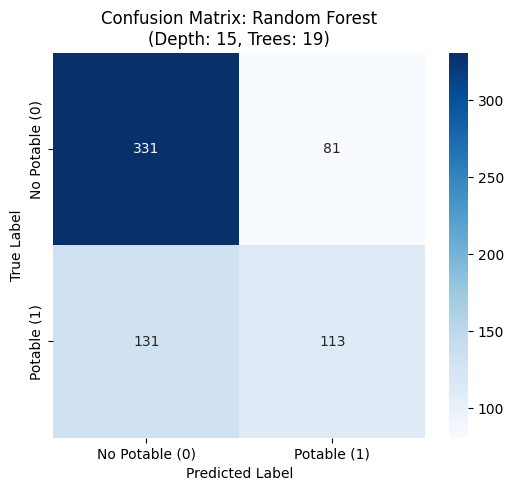

In [38]:
# confusion matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Potable (0)', 'Potable (1)'],
            yticklabels=['No Potable (0)', 'Potable (1)'])
plt.title(f"Confusion Matrix: Random Forest\n(Depth: {rand_search.best_params_['max_depth']}, Trees: {rand_search.best_params_['n_estimators']})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [39]:
# Probability
prob_pot_rf = pd.DataFrame(best_rf.predict_proba(X_test_imp), columns=['P(y=0|X)', 'P(y=1|X)'])
prob_pot_rf.head(15)

,P(y=0|X),P(y=1|X)
0,0.526759,0.473241
1,0.521633,0.478367
2,0.570521,0.429479
3,0.592962,0.407038
4,0.513384,0.486616
5,0.052632,0.947368
6,0.393138,0.606862
7,0.891107,0.108893
8,0.549129,0.450871
9,0.553170,0.446830


# Comparing results between models

In [44]:
report_svm_linear = classification_report(y_test, y_pred_linear, output_dict=True)
report_svm_rbf = classification_report(y_test, y_test_pred_rbf, output_dict=True)
report_rf = classification_report(y_test, y_test_pred_rf, output_dict=True)

def get_metric(report, name):
    # metrics for class 1
    metrics = report["1"] 
    metrics['accuracy'] = report['accuracy']
    return pd.Series(metrics, name=name)

# table
comparative_table = pd.concat([
    get_metric(report_svm_linear, 'SVM Linear'),
    get_metric(report_svm_rbf, 'SVM rbf'),
    get_metric(report_rf, 'Random Forest')
], axis=1).T

# get metrics
comparative_table = comparative_table[['accuracy', 'precision', 'recall', 'f1-score']].round(2)

print("\n" + "="*40)
print("Comparative  metrics table for class 1")
print("\n" + "="*40)   
print(comparative_table)


def get_metric(report, name):
    # metrics for class 0
    metrics = report["0"] 
    metrics['accuracy'] = report['accuracy']
    return pd.Series(metrics, name=name)

# table
comparative_table = pd.concat([
    get_metric(report_svm_linear, 'SVM Linear'),
    get_metric(report_svm_rbf, 'SVM rbf'),
    get_metric(report_rf, 'Random Forest')
], axis=1).T

# get metrics
comparative_table = comparative_table[['accuracy', 'precision', 'recall', 'f1-score']].round(2)

print("\n" + "="*40)
print("Comparative  metrics table for class 0")
print("\n" + "="*40)   
print(comparative_table)



Comparative  metrics table for class 1

               accuracy  precision  recall  f1-score
SVM Linear         0.63       0.00    0.00      0.00
SVM rbf            0.66       0.57    0.33      0.42
Random Forest      0.68       0.58    0.46      0.52

Comparative  metrics table for class 0

               accuracy  precision  recall  f1-score
SVM Linear         0.63       0.63    1.00      0.77
SVM rbf            0.66       0.68    0.85      0.76
Random Forest      0.68       0.72    0.80      0.76


In [41]:
tn_svm, fp_svm, fn_svm, tp_svm = cm_svm.ravel()
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("=======================================")
print("Confussion matrix elements")
print("=======================================")
from tabulate import tabulate
data = [ ["SVM Linear", tnl, fpl, fnl, tpl], ["SVM brf",tn_svm, fp_svm, fn_svm, tp_svm], ["Random Forest", tn_rf, fp_rf, fn_rf, tp_rf]]
print(tabulate(data, headers=["Model", "TN", "FP", "FN", "TP"]))

Confussion matrix elements
Model            TN    FP    FN    TP
-------------  ----  ----  ----  ----
SVM Linear      412     0   244     0
SVM brf         351    61   164    80
Random Forest   331    81   131   113


🔍  
* After evaluating multiple algorithms and performing hyperparameter optimization, the Random Forest seems to be a better model for water potability prediction. By optimizing the model using the F1-score as the primary metric,  Recall and F1 were increased for the positive class (water potability). 

* This small improvement in Recall and F1 shows the Random Forest model's ability to identify actual potable water sources.

# Feature importance

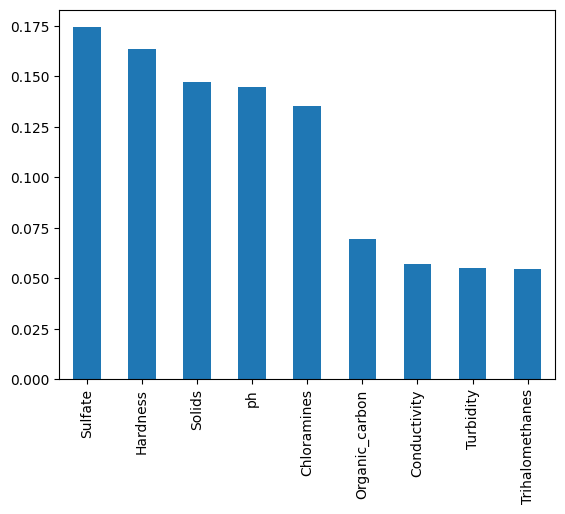

In [43]:
# Create a series containing feature importances from the model and feature names from the training data
feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot a simple bar chart
feature_importances.plot.bar();

🔍 
Finally, I analyzed the Feature Importance provided by the Random Forest model. 
* The results indicate that Sulfate, Hardness, and Solids are the most influential variables in determining water potability, collectively accounting for over 50% of the model's predictive power.
*  On the other hand, variables such as Turbidity and Trihalomethanes showed the lowest impact. This ranking indicates that mineral concentration and chemical composition are more critical for this specific dataset than physical properties like turbidity.

## 6) Conclusions

* Two models were considered in this project for the classification of water potability. Supported Vector Machine (SVM) and Random Forest.

* Compared to the SVM with RBF kernel, the Random Forest model performed better in water potability prediction. By optimizing the model using the F1-score,  both recall and F1-score improved relative to the SVM model. 

* If the goal is to detect unsafe water, Random Forest performs well, achieving a recall of 0.80 for non-potable water.

* However, performance on potable water remains limited (recall = 0.46), highlighting the difficulty of identifying safe water. The dataset exhibits two characteristics that make classification particularly challenging: it is both class-imbalanced and class-overlapped. When these two characteristics coexist, standard models are highly prone to producing biased decision boundaries, which significantly reduces Recall and F1 in the minority class.


## 7) References

1. [CF_Blog](https://careerfoundry.com/en/blog/data-analytics/how-to-find-outliers/)
2. [Outliers](https://stackoverflow.com/questions/39068214/how-to-count-outliers-for-all-columns-in-python)
3. [Normalization-Standarization](https://pmc.ncbi.nlm.nih.gov/articles/PMC3489534/#:~:text=We%20suggest%20that%20normalization%20be,imputation%2C%20significance%20analysis%20and%20visualization)
4. [Normalize after or before imputation](https://stats.stackexchange.com/questions/214728/should-data-be-normalized-before-or-after-imputation-of-missing-data)
5. [Medium_SVM](https://medium.com/data-science/svm-support-vector-machine-for-classification-710a009f6873)
6. [Class-Overlapping-Imbalanced](https://www.sciencedirect.com/science/article/abs/pii/S0031320323004193)